# Example of running and analysing the energy system model of the NL

In [27]:
import calliope
import pandas as pd

calliope.set_log_verbosity("INFO", include_solver_output=True)

# 1. Reference case
## 1.1. Create and solve the model

In [28]:
model = calliope.read_yaml('C:\\Users\\amran\\Downloads\\SEN1531_Integrated_Energy_sys\\SEN1531_Integrated_Energy_sys\\calliope_integrated\\model_starter_toolkit\\calliope_model\\model\\model.yaml')

[2026-03-14 16:01:05] INFO     Math init | loading pre-defined math.
[2026-03-14 16:01:05] INFO     Math init | loading math files {'base', 'milp', 'storage_inter_cluster', 'spores', 'operate'}.
[2026-03-14 16:01:05] INFO     Model: preprocessing data
[2026-03-14 16:01:05] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:06] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:06] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:06] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:06] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:06] INFO     Model: initialisation complete


In [29]:
model.inputs.sink_use_equals.to_series().dropna()

timesteps            nodes  techs       
2025-01-01 00:00:00  NLD    demand_power    12567.367
2025-01-01 01:00:00  NLD    demand_power    11937.461
2025-01-01 02:00:00  NLD    demand_power    11899.610
2025-01-01 03:00:00  NLD    demand_power    11692.961
2025-01-01 04:00:00  NLD    demand_power    11338.905
                                              ...    
2025-03-31 19:00:00  NLD    demand_power    13162.691
2025-03-31 20:00:00  NLD    demand_power    12410.781
2025-03-31 21:00:00  NLD    demand_power    10712.501
2025-03-31 22:00:00  NLD    demand_power     9444.831
2025-03-31 23:00:00  NLD    demand_power     9462.668
Name: sink_use_equals, Length: 2160, dtype: float64

In [30]:
# print(balance_price['system_balance'].dtype)
# print(balance_price['timesteps'].dtype)

# mask = pd.to_datetime(balance_price['timesteps']).isin(days_of_interest)
# print(mask.sum())  # how many matched rows?


In [31]:
import os, calliope
os.chdir(r"C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model")
model = calliope.read_yaml("model/model.yaml")
model.build()
model.solve()


print(model.results.attrs.get("termination_condition"))  # should be optimal/feasible
model.to_netcdf("results/default_results.nc")


[2026-03-14 16:01:06] INFO     Math init | loading pre-defined math.
[2026-03-14 16:01:06] INFO     Math init | loading math files {'base', 'milp', 'storage_inter_cluster', 'spores', 'operate'}.
[2026-03-14 16:01:06] INFO     Model: preprocessing data
[2026-03-14 16:01:06] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:07] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:07] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:07] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:07] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:07] INFO     Model: initialisation complete
[2026-03-14 16:01:07] INFO     Model: backend build starting
[2026-03-14

## 1.2. Do a first sense-check of the results

In [32]:
# Shadow price for the power system balance constraint
balance_price = model.backend.shadow_prices.get("system_balance").to_series().reset_index()
balance_price.head()

,nodes,carriers,timesteps,system_balance
0,NLD,hydrogen,2025-01-01 00:00:00,-0.0
1,NLD,hydrogen,2025-01-01 01:00:00,-0.0
2,NLD,hydrogen,2025-01-01 02:00:00,-0.0
3,NLD,hydrogen,2025-01-01 03:00:00,-0.0
4,NLD,hydrogen,2025-01-01 04:00:00,-0.0


<Axes: >

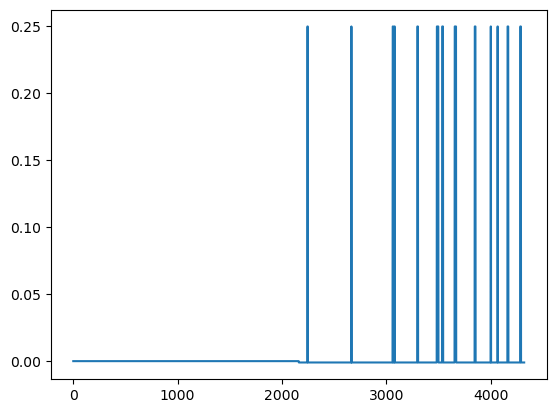

In [33]:
# Create a Date Range to select a few days in November to inspect visually
days_of_interest = pd.date_range('2025-01-01','2025-12-31',freq='h') 
# Plot the days of interest
balance_price['system_balance'].loc[balance_price['timesteps'].isin(days_of_interest)].plot()

Because the model is very simple, the price always matches the price of the CCGT unless renewables are capable of meeting demand by themselves. We can check that the value shown in the shadow price is indeed the marginal cost of the CCGT by performing a few steps. The marginal cost is, in fact, the ratio between the variable co

In [34]:
variable_costs = model.results.cost_operation_variable.to_series().dropna()
variable_costs.head()

nodes  techs            costs     timesteps          
NLD    battery_storage  monetary  2025-01-01 00:00:00    0.0
                                  2025-01-01 01:00:00    0.0
                                  2025-01-01 02:00:00    0.0
                                  2025-01-01 03:00:00    0.0
                                  2025-01-01 04:00:00    0.0
Name: cost_operation_variable, dtype: float64

In [35]:
generation = model.results.flow_out.to_series().dropna()
generation.head()

nodes  techs            carriers  timesteps          
NLD    battery_storage  power     2025-01-01 00:00:00    0.0
                                  2025-01-01 01:00:00    0.0
                                  2025-01-01 02:00:00    0.0
                                  2025-01-01 03:00:00    0.0
                                  2025-01-01 04:00:00    0.0
Name: flow_out, dtype: float64

In [36]:
# If we calculate the marginal generation costs per generator type,
# we should see an equivalence between the shadow price in any given
# hour and the marginal cost of the marginal generator in the merit order
marginal_generation_costs = variable_costs/generation
marginal_generation_costs.head()

nodes  techs            costs     timesteps            carriers
NLD    battery_storage  monetary  2025-01-01 00:00:00  power      NaN
                                  2025-01-01 01:00:00  power      NaN
                                  2025-01-01 02:00:00  power      NaN
                                  2025-01-01 03:00:00  power      NaN
                                  2025-01-01 04:00:00  power      NaN
dtype: float64

As expected, the marginal cost of CCGT equals the shadow price. CCGT is the marginal generator in the merit order.

In [37]:
# To check the merit order, we may look at a particular timestep
# and at the list of generators producing in that timestep in ascending cost order.
# The per-timestep selection is easier done before transforming to a Pandas series.
marginal_generation_costs_xr = model.results.cost_operation_variable / model.results.flow_out
# We select a specific hour of the year
my_timestep = '2025-01-02 04:00:00'
# And we select only generators, excluding curtailment and other techs
gen_techs = ['wind_offshore']
# gen_techs = ['solar_pv' ,'wind_offshore', 'wind_onshore', 'ccgt', 'nuclear'] 
# We can now inspect the marginal generation cost in that timestep
marginal_generation_cost_in_timestep = marginal_generation_costs_xr.sel(timesteps=my_timestep, carriers='power', costs='monetary', techs=gen_techs)
marginal_generation_cost_in_timestep.to_series().fillna(0).sort_values()

nodes  techs        
NLD    wind_offshore    0.0
dtype: float64

We see that CCGT, whose marginal generation costs match the shadow price, is the marginal generator. Nuclear isn't used; if it were, the shadow price would be higher and equal to its marginal cost. This can be double-checked by looking at the dispatch plots.

## 1.3. Export the results for further analysis at any later moment

In [38]:
# It is helpful to store the model results as a whole in NetCDF format, which Calliope can import back
# at any later time. 
model.to_netcdf('results/default_results.nc')


In [39]:
# Alternatively, results can be exported as a series of .csv files for inspection and analysis in Excel or
# other software that may benefit from .csv data
#overwrite the .csv files if they already exist
# model.to_csv('results/default_results_csv')

## 1.4. Produce some visualisations

In this example, we provide some pre-made plotting functionalities in the 'plotting_utilities.py' file, which you can import and apply as well as use as an example for making your own custom plots.

In [40]:
# Import some pre-made plotting functionalities as an example. You can use these, make your own, or simply
# create plots with your favourite Python library or non-Python tool, such as Excel
from plotting_utilities import plot_dispatch,plot_load_duration_curve

In [41]:
# Dispatch plots can be generated directly from the saved model results
plot_dispatch(model_path='results/default_results.nc', plot_export_path='results/default_dispatch.html')

[2026-03-14 16:01:16] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:16] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:16] INFO     Model: initialisation complete


In [42]:
# For generating load duration curves (LDCs), instead, we first need to import back the model results,
# then extract the time-varing variable of interest
model = calliope.read_netcdf('results/default_results.nc')

[2026-03-14 16:01:17] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:17] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:17] INFO     Model: initialisation complete


In [43]:
import pandas as pd

print("Termination:", model.results.attrs.get("termination_condition"))

# Energy totals (MWh over model horizon)
demand_served = model.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed = model.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed = model.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen = model.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

# Available wind energy from profile * installed cap
wind_avail = (
    model.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
    * model.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
).sum().item()

curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0

# Shadow price stats


sp = model.results.shadow_price_system_balance.to_series()
price_stats = sp.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

kpis = pd.Series({
    "Demand served (MWh)": demand_served,
    "Wind available (MWh)": wind_avail,
    "Wind generated (MWh)": wind_gen,
    "Curtailment (MWh)": curtailed,
    "Curtailment rate (%)": curtailment_rate,
    "Load shedding (MWh)": load_shed,
})

print(kpis)
print("\nSystem balance price stats:")
print(price_stats)



Termination: None
Demand served (MWh)     3.449209e+07
Wind available (MWh)    1.196558e+08
Wind generated (MWh)    1.196558e+08
Curtailment (MWh)       8.592521e+07
Curtailment rate (%)    7.181030e+01
Load shedding (MWh)     7.614751e+05
dtype: float64

System balance price stats:
mean    0.004787
50%     0.000000
95%     0.000000
max     0.250000
Name: shadow_price_system_balance, dtype: float64


## 2. Battery Scenario

Run only the battery pathway scenario and extract baseline + battery-specific KPIs.

In [44]:
scenario_name = "surplus_to_battery"
model_battery = calliope.read_yaml("model/model.yaml", scenario=scenario_name)
model_battery.build()
model_battery.solve()
print("Termination:", model_battery.results.attrs.get("termination_condition"))
model_battery.to_netcdf(f"results/{scenario_name}_results.nc")


[2026-03-14 16:01:17] INFO     Loading overrides from scenario: surplus_to_battery 
[2026-03-14 16:01:17] INFO     (scenarios, surplus_to_battery ) | Applying the following overrides: ['enable_battery_pathway'].
[2026-03-14 16:01:17] INFO     Math init | loading pre-defined math.
[2026-03-14 16:01:17] INFO     Math init | loading math files {'base', 'milp', 'storage_inter_cluster', 'spores', 'operate'}.
[2026-03-14 16:01:17] INFO     Model: preprocessing data
[2026-03-14 16:01:17] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:18] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:18] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:18] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:18] INFO     input data `name` not

In [45]:
plot_dispatch(
    model_path=f"results/{scenario_name}_results.nc",
    plot_export_path=f"results/{scenario_name}_dispatch.html",
)


[2026-03-14 16:01:26] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:26] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:26] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:26] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:26] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:26] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:26] INFO     Model: initialisation complete


In [46]:
import pandas as pd

m = calliope.read_netcdf(f"results/{scenario_name}_results.nc")

# Common KPIs
demand_served = m.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed = m.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen = m.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m.inputs.data_vars:
    wind_avail = (
        m.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
        * m.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    ).sum().item()
else:
    wind_avail = (
        m.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD")
        * m.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    ).sum().item()

curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0
sp = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats = sp.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

# Battery-specific KPIs
battery_charge = m.results.flow_in.sel(techs="battery_storage", carriers="power").sum().item()
battery_discharge = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
battery_losses = battery_charge - battery_discharge
battery_round_trip = (battery_discharge / battery_charge * 100) if battery_charge > 0 else 0

kpis_battery = pd.Series({
    "Demand served (MWh)": demand_served,
    "Wind available (MWh)": wind_avail,
    "Wind generated (MWh)": wind_gen,
    "Curtailment (MWh)": curtailed,
    "Curtailment rate (%)": curtailment_rate,
    "Load shedding (MWh)": load_shed,
    "Battery charge (MWh)": battery_charge,
    "Battery discharge (MWh)": battery_discharge,
    "Battery losses (MWh)": battery_losses,
    "Battery round-trip (%)": battery_round_trip,
})

print(kpis_battery)
print("\nPower system balance price stats:")
print(price_stats)


[2026-03-14 16:01:27] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:27] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:27] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:27] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:27] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:27] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:27] INFO     Model: initialisation complete
Demand served (MWh)        3.449209e+07
Wind available (MWh)       1.196558e+08
Wind generated (MWh)       1.196558e+08
Curtailment (MWh)          8.576753e+07
Curtailment rate (%)       7.167852e+01
Load shedding (MWh)        7.070962e+05
Battery charge (M

## 3. Hydrogen Scenario

Run the hydrogen pathway scenario, export results, and compute hydrogen-specific KPIs.

In [47]:
scenario_name_h2 = "surplus_to_hydrogen"
model_h2 = calliope.read_yaml("model/model.yaml", scenario=scenario_name_h2)
model_h2.build()
model_h2.solve()
print("Termination:", model_h2.results.attrs.get("termination_condition"))
model_h2.to_netcdf(f"results/{scenario_name_h2}_results.nc")


[2026-03-14 16:01:27] INFO     Loading overrides from scenario: surplus_to_hydrogen 
[2026-03-14 16:01:27] INFO     (scenarios, surplus_to_hydrogen ) | Applying the following overrides: ['enable_hydrogen_pathway'].
[2026-03-14 16:01:27] INFO     Math init | loading pre-defined math.
[2026-03-14 16:01:27] INFO     Math init | loading math files {'base', 'milp', 'storage_inter_cluster', 'spores', 'operate'}.
[2026-03-14 16:01:27] INFO     Model: preprocessing data
[2026-03-14 16:01:27] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:28] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:28] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:28] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:28] INFO     input data `name` 

In [48]:
plot_dispatch(
    model_path=f"results/{scenario_name_h2}_results.nc",
    plot_export_path=f"results/{scenario_name_h2}_dispatch.html",
)


[2026-03-14 16:01:36] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:36] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:36] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:36] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:36] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:36] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:36] INFO     Model: initialisation complete


In [49]:
m_h2 = calliope.read_netcdf(f"results/{scenario_name_h2}_results.nc")

demand_served_h2 = m_h2.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed_h2 = m_h2.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed_h2 = m_h2.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen_h2 = m_h2.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m_h2.inputs.data_vars:
    wind_avail_h2 = (m_h2.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD") * m_h2.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()
else:
    wind_avail_h2 = (m_h2.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD") * m_h2.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()

curtailment_rate_h2 = (curtailed_h2 / wind_avail_h2 * 100) if wind_avail_h2 > 0 else 0
sp_h2 = m_h2.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats_h2 = sp_h2.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

electrolyser_in = m_h2.results.flow_in.sel(techs="electrolyser", carriers="power").sum().item()
fuel_cell_out = m_h2.results.flow_out.sel(techs="fuel_cell", carriers="power").sum().item()
h2_storage_in = m_h2.results.flow_in.sel(techs="hydrogen_storage", carriers="hydrogen").sum().item()
h2_storage_out = m_h2.results.flow_out.sel(techs="hydrogen_storage", carriers="hydrogen").sum().item()
h2_round_trip = (fuel_cell_out / electrolyser_in * 100) if electrolyser_in > 0 else 0

kpis_hydrogen = pd.Series({
    "Demand served (MWh)": demand_served_h2,
    "Wind available (MWh)": wind_avail_h2,
    "Wind generated (MWh)": wind_gen_h2,
    "Curtailment (MWh)": curtailed_h2,
    "Curtailment rate (%)": curtailment_rate_h2,
    "Load shedding (MWh)": load_shed_h2,
    "Electrolyser input (MWh)": electrolyser_in,
    "Fuel cell output (MWh)": fuel_cell_out,
    "H2 storage charge (MWh_H2)": h2_storage_in,
    "H2 storage discharge (MWh_H2)": h2_storage_out,
    "Power-to-power via H2 (%)": h2_round_trip,
})

print(kpis_hydrogen)
print("\nPower system balance price stats:")
print(price_stats_h2)


[2026-03-14 16:01:36] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:36] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:36] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:37] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:37] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:37] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:37] INFO     Model: initialisation complete
Demand served (MWh)              3.449209e+07
Wind available (MWh)             1.196558e+08
Wind generated (MWh)             1.196558e+08
Curtailment (MWh)                8.493624e+07
Curtailment rate (%)             7.098380e+01
Load shedding (MWh)        

## 4. Big User Scenario

Run the flexible large-user pathway scenario and compute user-specific KPIs.

In [50]:
scenario_name_user = "surplus_to_big_user"
model_user = calliope.read_yaml("model/model.yaml", scenario=scenario_name_user)
model_user.build()
model_user.solve()
print("Termination:", model_user.results.attrs.get("termination_condition"))
model_user.to_netcdf(f"results/{scenario_name_user}_results.nc")


[2026-03-14 16:01:37] INFO     Loading overrides from scenario: surplus_to_big_user 
[2026-03-14 16:01:37] INFO     (scenarios, surplus_to_big_user ) | Applying the following overrides: ['enable_big_user_pathway'].
[2026-03-14 16:01:37] INFO     Math init | loading pre-defined math.
[2026-03-14 16:01:37] INFO     Math init | loading math files {'base', 'milp', 'storage_inter_cluster', 'spores', 'operate'}.
[2026-03-14 16:01:37] INFO     Model: preprocessing data
[2026-03-14 16:01:37] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:37] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:37] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:37] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:37] INFO     input data `name` 

In [51]:
plot_dispatch(
    model_path=f"results/{scenario_name_user}_results.nc",
    plot_export_path=f"results/{scenario_name_user}_dispatch.html",
)


[2026-03-14 16:01:46] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:46] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:46] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:46] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:46] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:46] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:46] INFO     Model: initialisation complete


In [52]:
m_user = calliope.read_netcdf(f"results/{scenario_name_user}_results.nc")

demand_served_user = m_user.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed_user = m_user.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed_user = m_user.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen_user = m_user.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m_user.inputs.data_vars:
    wind_avail_user = (m_user.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD") * m_user.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()
else:
    wind_avail_user = (m_user.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD") * m_user.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()

curtailment_rate_user = (curtailed_user / wind_avail_user * 100) if wind_avail_user > 0 else 0
sp_user = m_user.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats_user = sp_user.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

big_user_energy = m_user.results.flow_in.sel(techs="demand_big_user", carriers="power").sum().item()
big_user_avg_mw = big_user_energy / 8760
big_user_revenue_kEUR = big_user_energy * 0.02

kpis_big_user = pd.Series({
    "Demand served (MWh)": demand_served_user,
    "Wind available (MWh)": wind_avail_user,
    "Wind generated (MWh)": wind_gen_user,
    "Curtailment (MWh)": curtailed_user,
    "Curtailment rate (%)": curtailment_rate_user,
    "Load shedding (MWh)": load_shed_user,
    "Big user served (MWh)": big_user_energy,
    "Big user avg load (MW)": big_user_avg_mw,
    "Big user revenue equivalent (kEUR)": big_user_revenue_kEUR,
})

print(kpis_big_user)
print("\nPower system balance price stats:")
print(price_stats_user)


[2026-03-14 16:01:47] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:47] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:47] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:47] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:47] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:47] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:47] INFO     Model: initialisation complete
Demand served (MWh)                   3.449209e+07
Wind available (MWh)                  1.196558e+08
Wind generated (MWh)                  1.196558e+08
Curtailment (MWh)                     8.077043e+07
Curtailment rate (%)                  6.750230e+01
Lo

## 5. Compare The Three Scenarios

Build one comparison table from saved NetCDF results.

In [53]:
import numpy as np
import pandas as pd
from pathlib import Path

def _wind_available(model):
    if "source_use_equals" in model.inputs.data_vars:
        profile = model.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
    else:
        profile = model.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD")
    cap = model.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    return (profile * cap).sum().item()

def compute_kpis(nc_path, scenario_type):
    m = calliope.read_netcdf(nc_path)
    demand_served = m.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
    curtailed = m.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
    load_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
    wind_gen = m.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()
    wind_avail = _wind_available(m)
    curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0

    if "shadow_price_system_balance" in m.results.data_vars:
        sp = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
        price_mean = sp.mean() if len(sp) else np.nan
        price_p95 = sp.quantile(0.95) if len(sp) else np.nan
        price_max = sp.max() if len(sp) else np.nan
    else:
        price_mean, price_p95, price_max = np.nan, np.nan, np.nan

    out = {
        "Demand served (MWh)": demand_served,
        "Wind available (MWh)": wind_avail,
        "Wind generated (MWh)": wind_gen,
        "Curtailment (MWh)": curtailed,
        "Curtailment rate (%)": curtailment_rate,
        "Load shedding (MWh)": load_shed,
        "Price mean (kEUR/MWh)": price_mean,
        "Price p95 (kEUR/MWh)": price_p95,
        "Price max (kEUR/MWh)": price_max,
    }

    if scenario_type == "battery":
        ch = m.results.flow_in.sel(techs="battery_storage", carriers="power").sum().item()
        dis = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
        out["Battery discharge (MWh)"] = dis
        out["Battery round-trip (%)"] = (dis / ch * 100) if ch > 0 else np.nan
    elif scenario_type == "hydrogen":
        el = m.results.flow_in.sel(techs="electrolyser", carriers="power").sum().item()
        fc = m.results.flow_out.sel(techs="fuel_cell", carriers="power").sum().item()
        out["Electrolyser input (MWh)"] = el
        out["Fuel cell output (MWh)"] = fc
        out["Power-to-power via H2 (%)"] = (fc / el * 100) if el > 0 else np.nan
    elif scenario_type == "big_user":
        bu = m.results.flow_in.sel(techs="demand_big_user", carriers="power").sum().item()
        out["Big user served (MWh)"] = bu
        out["Big user revenue equivalent (kEUR)"] = bu * 0.02

    return out

scenario_meta = {
    "surplus_to_battery": "battery",
    "surplus_to_hydrogen": "hydrogen",
    "surplus_to_big_user": "big_user",
}

rows = {}
for sc, kind in scenario_meta.items():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        print(f"Skipping {sc}: {nc} not found. Run that scenario cell first.")
        continue
    rows[sc] = compute_kpis(str(nc), kind)

if not rows:
    raise RuntimeError("No scenario result files found. Run scenario solve cells first.")

kpi_compare = pd.DataFrame(rows).T
kpi_compare


[2026-03-14 16:01:47] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:47] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:47] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:47] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:47] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:47] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:01:47] INFO     Model: initialisation complete
[2026-03-14 16:01:48] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:01:48] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:01:48] INFO     input data `color` not defined in model math; it will not be availa

,Demand served (MWh),Wind available (MWh),Wind generated (MWh),Curtailment (MWh),Curtailment rate (%),Load shedding (MWh),Price mean (kEUR/MWh),Price p95 (kEUR/MWh),Price max (kEUR/MWh),Battery discharge (MWh),Battery round-trip (%),Electrolyser input (MWh),Fuel cell output (MWh),Power-to-power via H2 (%),Big user served (MWh),Big user revenue equivalent (kEUR)
surplus_to_battery,34492087.41,119655823.0,119655823.0,8.576753e+07,71.678524,707096.231046,0.009110,-0.001,0.25,2.382683e+06,95.844538,NaN,NaN,NaN,NaN,NaN
surplus_to_hydrogen,34492087.41,119655823.0,119655823.0,8.493624e+07,70.983795,739213.634985,0.009458,-0.001,0.25,NaN,NaN,1.558202e+06,591497.364593,37.960252,NaN,NaN
surplus_to_big_user,34492087.41,119655823.0,119655823.0,8.077043e+07,67.502298,761475.156518,0.009730,-0.001,0.25,NaN,NaN,NaN,NaN,NaN,5.154781e+06,103095.61388


## 6. Extra Diagnostics (Non-Redundant)

These metrics complement `kpi_compare` with hour-based reliability indicators and utilization checks.

In [55]:
import numpy as np
import pandas as pd
from pathlib import Path

# Reuse scenario_meta from above if available
try:
    scenario_meta
except NameError:
    scenario_meta = {
        "surplus_to_battery": "battery",
        "surplus_to_hydrogen": "hydrogen",
        "surplus_to_big_user": "big_user",
    }

diag_rows = {}
for sc, kind in scenario_meta.items():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue

    m = calliope.read_netcdf(str(nc))
    ts_curt = m.results.flow_in.sel(techs="curtailment", carriers="power").to_series().fillna(0)
    ts_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").to_series().fillna(0)

    if "shadow_price_system_balance" in m.results.data_vars:
        ts_price = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
    else:
        ts_price = pd.Series(dtype=float)

    row = {
        "Curtailment hours (>0 MW)": int((ts_curt > 1e-6).sum()),
        "Load shedding hours (>0 MW)": int((ts_shed > 1e-6).sum()),
        "Peak curtailment (MW)": float(ts_curt.max()) if len(ts_curt) else np.nan,
        "Peak load shedding (MW)": float(ts_shed.max()) if len(ts_shed) else np.nan,
        "Scarcity price hours (>=0.249)": int((ts_price >= 0.249).sum()) if len(ts_price) else np.nan,
    }

    if kind == "battery":
        dis = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
        try:
            e_cap = float(m.inputs.storage_cap.sel(nodes="NLD", techs="battery_storage").item())
        except Exception:
            e_cap = np.nan
        row["Battery equivalent full cycles"] = dis / e_cap if e_cap and e_cap > 0 else np.nan

    if kind == "hydrogen":
        el_in = m.results.flow_in.sel(techs="electrolyser", carriers="power").to_series().fillna(0)
        try:
            p_cap = float(m.inputs.flow_cap.sel(nodes="NLD", techs="electrolyser").item())
        except Exception:
            p_cap = np.nan
        row["Electrolyser utilization (%)"] = 100 * el_in.mean() / p_cap if p_cap and p_cap > 0 else np.nan

    if kind == "big_user":
        bu = m.results.flow_in.sel(techs="demand_big_user", carriers="power").to_series().fillna(0)
        try:
            bu_max = float(m.inputs.sink_use_max.sel(techs="demand_big_user").item())
        except Exception:
            bu_max = np.nan
        row["Big user utilization (%)"] = 100 * bu.mean() / bu_max if bu_max and bu_max > 0 else np.nan

    diag_rows[sc] = row

diag_compare = pd.DataFrame(diag_rows).T
diag_compare


[2026-03-14 16:10:22] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:10:22] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:10:22] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:10:22] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:10:22] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:10:22] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:10:22] INFO     Model: initialisation complete
[2026-03-14 16:10:22] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:10:22] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:10:22] INFO     input data `color` not defined in model math; it will not be availa

,Curtailment hours (>0 MW),Load shedding hours (>0 MW),Peak curtailment (MW),Peak load shedding (MW),Scarcity price hours (>=0.249),Battery equivalent full cycles,Electrolyser utilization (%),Big user utilization (%)
surplus_to_battery,2073.0,87.0,61855.016606,16703.677471,87.0,484.285223,NaN,NaN
surplus_to_hydrogen,2070.0,90.0,61426.770978,16782.372717,90.0,NaN,72.138977,NaN
surplus_to_big_user,2069.0,2160.0,59421.038201,16964.675000,91.0,NaN,NaN,95.458902


In [56]:
import plotly.express as px

# Price duration curves (power carrier)
price_frames = []
for sc in scenario_meta.keys():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue
    m = calliope.read_netcdf(str(nc))
    if "shadow_price_system_balance" not in m.results.data_vars:
        continue
    p = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna().sort_values(ascending=False).reset_index(drop=True)
    price_frames.append(pd.DataFrame({"hour_rank": p.index + 1, "price_kEUR_per_MWh": p.values, "scenario": sc}))

if price_frames:
    df_price_duration = pd.concat(price_frames, ignore_index=True)
    fig = px.line(df_price_duration, x="hour_rank", y="price_kEUR_per_MWh", color="scenario", title="Power Price Duration Curves")
    fig.show()
else:
    print("No price data available to plot.")


[2026-03-14 16:10:28] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:10:28] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:10:28] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:10:28] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:10:29] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:10:29] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:10:29] INFO     Model: initialisation complete
[2026-03-14 16:10:29] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:10:29] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:10:29] INFO     input data `color` not defined in model math; it will not be availa

In [58]:
from pathlib import Path

curt_frames = []

for sc in scenario_meta.keys():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue

    m = calliope.read_netcdf(str(nc))

    c = m.results.flow_in.sel(techs="curtailment", carriers="power").fillna(0)

    # Collapse non-time dims if present (e.g., nodes)
    for d in [d for d in c.dims if d != "timesteps"]:
        c = c.sum(d)

    monthly = c.groupby("timesteps.month").sum().to_series()

    curt_frames.append(
        pd.DataFrame(
            {"month": monthly.index, "curtailment_MWh": monthly.values, "scenario": sc}
        )
    )

if curt_frames:
    df_monthly_curt = pd.concat(curt_frames, ignore_index=True)
    fig = px.bar(
        df_monthly_curt,
        x="month",
        y="curtailment_MWh",
        color="scenario",
        barmode="group",
        title="Monthly Curtailment by Scenario",
    )
    fig.show()
else:
    print("No curtailment data available to plot.")


[2026-03-14 16:11:49] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:11:49] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:11:49] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:11:49] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:11:49] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:11:49] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 16:11:49] INFO     Model: initialisation complete
[2026-03-14 16:11:49] INFO     Model: preprocessing data (reentry)
[2026-03-14 16:11:49] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 16:11:49] INFO     input data `color` not defined in model math; it will not be availa